### Import Libraries.

In [10]:
import pandas as pd 
import numpy as np 

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [2]:
### Overview of dataset.

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [4]:
df.sample(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
124,0.09849,0.0,25.65,0,0.581,5.879,95.8,2.0063,2,188,19.1,379.38,17.58,18.8
176,0.07022,0.0,4.05,0,0.510,6.020,47.2,3.5549,5,296,16.6,393.23,10.11,23.2
411,14.05070,0.0,18.10,0,0.597,6.657,100.0,1.5275,24,666,20.2,35.05,21.22,17.2
48,0.25387,0.0,6.91,0,0.448,5.399,95.3,5.8700,3,233,17.9,396.90,30.81,14.4
475,6.39312,0.0,18.10,0,0.584,6.162,97.4,2.2060,24,666,20.2,302.76,24.10,13.3


In [6]:
# separate the feature and target. 
X = df.iloc[ : , : 13]
y = df['medv']

In [14]:
# model object. 
model = LinearRegression() 

# k-fold object. 
kfold = KFold(n_splits = 5, shuffle=True, random_state=12)

# tarining. 
scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

# scores. 
scores

array([0.74840317, 0.67767952, 0.72592914, 0.73157826, 0.69457569])

In [15]:
# r2 score for all the models. 
print('R2 Score of all the models we trained : ', scores)

R2 Score of all the models we trained :  [0.74840317 0.67767952 0.72592914 0.73157826 0.69457569]


In [16]:
# mean of all the scores. 
print('Average accuracy : ', np.mean(scores))

Average accuracy :  0.7156331552406614


### Variance when we used the KFold CV.

C:\Users\Mohd Uzaif\AppData\Local\Temp\ipykernel_13460\1783677333.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


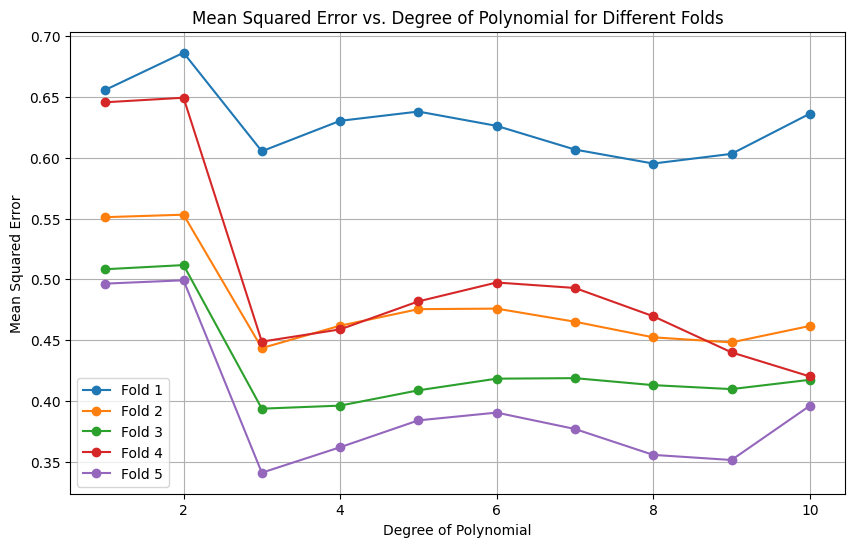

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Load the Auto MPG dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

# Drop rows with missing values
auto_mpg = auto_mpg.dropna()

# Define features and target
features = auto_mpg[['Horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['MPG']

# Convert to numpy arrays for easier manipulation
X = features.to_numpy()
y = target.to_numpy()

# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# Create a plot
plt.figure(figsize=(10, 6))

# Create a 10-fold cross validator
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # List to store Mean Squared Errors
    mse_list = []

    for degree in degrees:
        # Add polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Create a linear regression model
        model = LinearRegression()

        # Train the model on the polynomial features training data
        model.fit(X_train_poly, y_train)

        # Use the trained model to predict the target values in the test set
        y_pred = model.predict(X_test_poly)

        # Calculate the Mean Squared Error of the model on the test set
        mse = mean_squared_error(y_test, y_pred)

        # Store the Mean Squared Error in the list
        mse_list.append(mse)

    # Plot the Mean Squared Error as a function of the degree of the polynomial for the current fold
    plt.plot(degrees, mse_list, marker='o', label=f'Fold {i + 1}')

plt.title('Mean Squared Error vs. Degree of Polynomial for Different Folds')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


### Variance in results when we used Hold one out.

C:\Users\Mohd Uzaif\AppData\Local\Temp\ipykernel_13460\1587718092.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


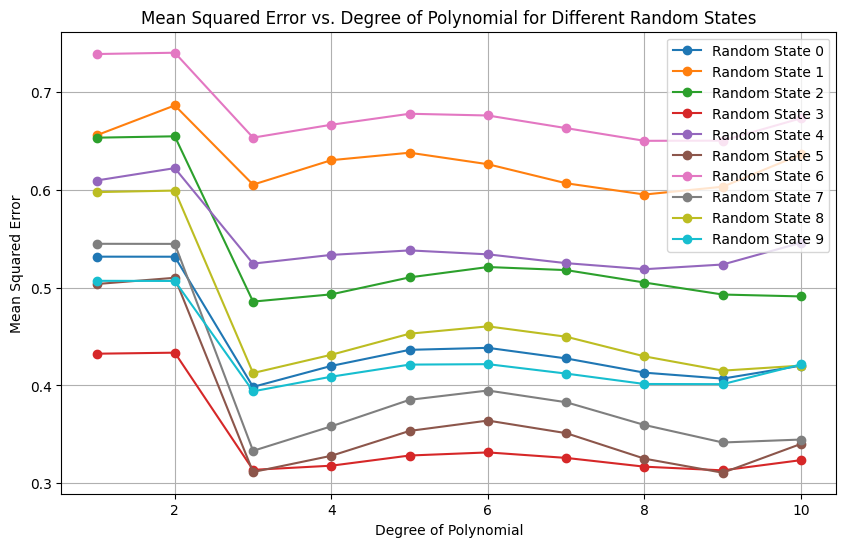

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Load the Auto MPG dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

# Drop rows with missing values
auto_mpg = auto_mpg.dropna()

# Define features and target
features = auto_mpg[['Horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['MPG']

# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# List of random states
random_states = list(range(10))

# Create a plot
plt.figure(figsize=(10, 6))

for i, random_state in enumerate(random_states):
    # Split the dataset into a training set and a test set
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=random_state)

    # List to store Mean Squared Errors
    mse_list = []

    for degree in degrees:
        # Add polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Create a linear regression model
        model = LinearRegression()

        # Train the model on the polynomial features training data
        model.fit(X_train_poly, y_train)

        # Use the trained model to predict the target values in the test set
        y_pred = model.predict(X_test_poly)

        # Calculate the Mean Squared Error of the model on the test set
        mse = mean_squared_error(y_test, y_pred)

        # Store the Mean Squared Error in the list
        mse_list.append(mse)

    # Plot the Mean Squared Error as a function of the degree of the polynomial for the current random state
    plt.plot(degrees, mse_list, marker='o', label=f'Random State {random_state}')

plt.title('Mean Squared Error vs. Degree of Polynomial for Different Random States')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()
